<div class="alert alert-block alert-success">

# App 1: 多模态评分预测模型 (Multimodal Rating Prediction)

**项目:** FIT5196 A1 (Extended Part)   
**模块:** App 1 - Rating Prediction  
**环境:** A100 GPU (40GB) + High-RAM CPU (83.5GB)  
**日期:** 2025.11.21

</div>

**项目概览:**  
本 Notebook 是 App 1 的模型训练模块。基于预处理后的 Google Maps 评论数据集，构建双塔多模态分类模型（Two-Tower Architecture），利用评论文本与用户上传图片共同预测 1-5 星评分。

**核心特性:**
* **架构:** RoBERTa-Base (Text) + Swin-Base (Image) + LoRA 微调。
* **工程:** 采用全内存预加载 (In-Memory Caching) 与条件计算 (Conditional Computation) 策略，在 A100 环境下实现高吞吐训练。

<div class="alert alert-block alert-info">

## 数据概况与训练管道 (Data Profile & Training Pipeline)

### 1. 数据统计 (Data Statistics)
数据源自加利福尼亚州 Google Maps 商家评论 (GroupALL)，经 `01_Preprocessing.ipynb` 清洗与平衡后：

* **数据规模:**
    * 原始数据: 5,767,463 行 (商家数: 29,088)
    * 训练数据 (App 1): **2,358,928 行** (Train: 1.88M / Val: 0.23M / Test: 0.23M)
* **模态分布:**
    * **纯文本样本:** 约 92% (无图片)
    * **多模态样本:** 约 8% (含图片)
* **特征分布:**
    * **文本:** 75% 的评论长度在 19 词以内 (Max: 1528)，截断长度设为 128。
    * **图片:** 涉及约 **95,379** 张唯一图片 (已去重加载至内存)。
* **标签分布:** 原始数据存在严重长尾分布 (5星主导)，已通过欠采样策略平衡各类样本比例。

### 2. 模型架构 (Model Architecture)
采用双塔结构提取多模态特征，并通过 LoRA (Low-Rank Adaptation) 进行参数高效微调：
* **文本塔 (Text Tower):** `RoBERTa-Base`
    * 包含 1.25亿参数，处理短文本情感语义。
* **视觉塔 (Image Tower):** `Swin-Base`
    * 包含 8800万参数，处理餐厅环境、食物等视觉特征。
    * **条件计算 (Conditional Computation):** 针对 92% 的无图样本，模型在前向传播中自动跳过视觉塔计算，仅对含图样本启用 Swin Transformer。
* **融合层 (Fusion):** 特征拼接 (Concatenation) -> MLP -> Softmax 分类。

### 3. 工程策略 (Engineering Strategy)
* **全内存预加载 (In-Memory Caching):** 利用 80GB+ 系统内存，在训练前将所有图片解码并 Resize 至 256x256 驻留内存，消除磁盘 I/O 瓶颈。
* **混合精度 (Mixed Precision):** 全程启用 FP16 (AMP) 加速计算。

</div>

## Step 1. 环境配置与数据搬运 (Environment & Data Setup)
**说明:**
配置依赖库并建立数据通道。
* **环境依赖:** 安装 `transformers`, `peft`, `accelerate` 等深度学习库。
* **数据加载:** 将清洗后的 Feather 数据集与压缩图片包 (`images.zip`) 从 Google Drive 迁移至 Colab 虚拟机本地 SSD (`/content/data`) 并解压，确保存储读取的低延迟。

In [1]:
# ==========================================
# 1. 环境配置与数据搬运 (Environment & Data Setup)
# ==========================================

# 1.1 安装依赖库 (如果尚未安装)
# - transformers: HuggingFace 模型库
# - timm: 图像模型库 (虽然主要用HF的Swin，但保留timm以备不时之需)
# - peft: LoRA 微调库
# - accelerate: 混合精度训练支持
try:
    import peft
    import transformers
except ImportError:
    print("正在安装依赖库...")
    !pip install -q transformers peft accelerate timm

import os
import shutil
import torch
from google.colab import drive

# 1.2 挂载 Google Drive
print("正在挂载 Google Drive...")
drive.mount('/content/drive')

# 1.3 定义路径
# 请根据你在 Drive 中的实际文件夹名称修改 DRIVE_BASE_PATH
DRIVE_BASE_PATH = '/content/drive/MyDrive/FIT5196_A1_Extension/App1'

# Colab 虚拟机本地路径 (速度快)
COLAB_DATA_DIR = '/content/data'
COLAB_IMG_DIR = '/content/images'

# 1.4 数据搬运与解压 (关键步骤)
print("\n正在检查并搬运数据...")

# (1) 搬运 Feather 数据文件
os.makedirs(COLAB_DATA_DIR, exist_ok=True)
for file_name in ['App1_Data_Train.ftr', 'App1_Data_Val.ftr', 'App1_Data_Test.ftr']:
    src = os.path.join(DRIVE_BASE_PATH, file_name)
    dst = os.path.join(COLAB_DATA_DIR, file_name)

    if not os.path.exists(dst):
        if os.path.exists(src):
            print(f"正在复制 {file_name} 到本地虚拟机...")
            shutil.copy(src, dst)
        else:
            print(f"警告: 在 Drive 中未找到 {file_name}，请检查路径！")
    else:
        print(f"文件已存在，跳过: {file_name}")

# (2) 搬运并解压图片 (images.zip)
zip_path_drive = os.path.join(DRIVE_BASE_PATH, 'images.zip')
zip_path_colab = '/content/images.zip'

if not os.path.exists(COLAB_IMG_DIR):
    # 检查本地是否已经有解压好的文件夹，如果没有才执行
    if os.path.exists(zip_path_drive):
        if not os.path.exists(zip_path_colab):
            print("正在从 Drive 复制 images.zip (这可能需要几分钟)...")
            shutil.copy(zip_path_drive, zip_path_colab)

        print("正在解压 images.zip...")
        # -q: 静默模式, -d: 指定目录
        !unzip -q {zip_path_colab} -d {COLAB_IMG_DIR}
        print("解压完成！")
    else:
        print("错误: 在 Drive 中未找到 images.zip，请确保已上传！")
else:
    print("图片目录已存在，跳过解压。")

print("\n环境准备就绪！")
print(f"数据路径: {COLAB_DATA_DIR}")
print(f"图片路径: {COLAB_IMG_DIR}")

正在挂载 Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

正在检查并搬运数据...
文件已存在，跳过: App1_Data_Train.ftr
文件已存在，跳过: App1_Data_Val.ftr
文件已存在，跳过: App1_Data_Test.ftr
图片目录已存在，跳过解压。

环境准备就绪！
数据路径: /content/data
图片路径: /content/images


## Step 2. 全局参数配置 (Configuration)
**说明:**
定义模型超参数与训练策略。针对 A100 40GB 显存与 12核 CPU 环境进行了适配。

| 参数 (Parameter) | 设定值 (Value) | 说明 (Description) |
| :--- | :--- | :--- |
| **Model (Text)** | `roberta-base` | 平衡推理速度与语义理解能力 |
| **Model (Image)** | `swin-base` | 微软 Swin Transformer (Patch4 Window7 224) |
| **Epochs** | **8** | 配合早停机制，通常在 5-6 轮收敛 |
| **Batch Size** | **512** | 高显存利用率配置，配合条件计算策略 |
| **Accumulation** | **1** | 不使用梯度累积，直接反向传播 |
| **Workers** | **8** | 利用多核 CPU 进行数据预取 |
| **LoRA Learning Rate** | `1e-4` | 预训练层的微调学习率 |
| **Head Learning Rate** | `1e-3` | 分类头 (随机初始化) 使用较大学习率 |
| **Patience** | **2** | 验证集 F1-Macro 不提升时的容忍轮数 |
| **Max Len** | **128** | 文本截断长度，覆盖 99% 样本 |

In [2]:
import os
print(f"CPU Cores: {os.cpu_count()}")

CPU Cores: 12


In [3]:
# ==========================================
# 2. 全局参数配置 (Configuration)
# ==========================================

# 开启 cuDNN 自动寻优，针对固定输入尺寸 (224x224) 提速 10-20%
torch.backends.cudnn.benchmark = True

class Config:
    # 路径配置
    TRAIN_PATH = f'{COLAB_DATA_DIR}/App1_Data_Train.ftr'
    VAL_PATH = f'{COLAB_DATA_DIR}/App1_Data_Val.ftr'
    # 注意: 解压后的图片可能在 images/ 或 images/03_images_raw/ 下，请根据实际解压结果调整
    # 这里假设 zip 直接解压出图片文件在 COLAB_IMG_DIR 下
    IMAGE_DIR = COLAB_IMG_DIR

    # 模型配置
    TEXT_MODEL = 'roberta-base'           # 文本塔 (HuggingFace ID)
    IMAGE_MODEL = 'microsoft/swin-base-patch4-window7-224' # 图片塔 (HuggingFace ID)
    NUM_CLASSES = 5                       # 1-5星
    MAX_LEN = 128                         # 文本截断长度
    DROPOUT = 0.3

    # 训练超参
    EPOCHS = 8                             # 230万数据量巨大，8轮足够收敛
    BATCH_SIZE = 512                       # 物理 Batch Size
    ACCUMULATION_STEPS = 1                 # 梯度累积步数
    NUM_WORKERS = 8

    # 学习率 (分层设置)
    LR_TEXT = 1e-4                        # RoBERTa LoRA
    LR_IMG = 1e-4                         # Swin LoRA
    LR_HEAD = 1e-3                        # Classifier Head
    WEIGHT_DECAY = 0.01

    # 早停与保存
    PATIENCE = 2
    SEED = 42

# 设置随机种子以保证复现性
def seed_everything(seed):
    import random
    import numpy as np
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True

seed_everything(Config.SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using Device: {device}")

Using Device: cuda


## Step 3. 数据集与增强 (InMemoryDataset)
**说明:**
实现基于内存驻留的高性能数据集类。
* **逻辑:** `__getitem__` 直接从内存字典 (`self.img_cache`) 获取预处理好的 PIL 图片对象，避免磁盘读取和解码开销。
* **增强 (Transforms):** 仅在训练时应用 `RandomCrop` (224px)、`HorizontalFlip` 和 `ColorJitter`，验证时仅做 `CenterCrop`。

In [4]:
# ==========================================
# 3. 数据集与增强 (Dataset & Transforms)
# ==========================================

import pandas as pd
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from transformers import AutoTokenizer

# ⚠️ 修改增强策略：
# 因为我们会在加载时就把图片统一 Resize 到 256 存入内存
# 所以这里只需要负责裁剪和增强，去掉昂贵的 Resize 操作
train_transforms = transforms.Compose([
    transforms.RandomCrop(224), # 从内存里的 256x256 裁剪出 224
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.CenterCrop(224), # 验证集居中裁剪
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class InMemoryDataset(Dataset):
    def __init__(self, df, img_cache, tokenizer, max_len, is_train=True):
        self.df = df
        # img_cache 是一个字典: {'filename': PIL.Image对象}
        self.img_cache = img_cache
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.is_train = is_train
        self.transforms = train_transforms if is_train else val_transforms

        # 标签处理
        self.df['label'] = self.df['review_rating'].astype(int) - 1

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        text = str(row['review_text'])
        label = row['label']
        img_files = row['img_filenames']

        # 1. 文本处理 (极速)
        inputs = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )
        input_ids = inputs['input_ids'].squeeze(0)
        attention_mask = inputs['attention_mask'].squeeze(0)

        # 2. 图片处理 (直接从内存拿！)
        image_tensor = torch.zeros((3, 224, 224))
        img_mask = torch.tensor(0.0)

        if img_files is not None and len(img_files) > 0:
            if isinstance(img_files, np.ndarray): img_files = img_files.tolist()

            # 训练时随机抽一张
            target_file = np.random.choice(img_files) if self.is_train else img_files[0]

            # === 核心差异 ===
            # 直接从 self.img_cache 字典里取，不做 IO，不做解码，不做 Resize
            if target_file in self.img_cache:
                img_obj = self.img_cache[target_file]
                image_tensor = self.transforms(img_obj) # 只做 Crop 和 Flip，飞快
                img_mask = torch.tensor(1.0)

        return {
            'input_ids': input_ids,
            'attention_mask': attention_mask,
            'image': image_tensor,
            'img_mask': img_mask,
            'label': torch.tensor(label, dtype=torch.long)
        }

## Step 4. 模型架构 (Model Architecture: RoBERTa + Swin + LoRA)
**目标:** 定义双塔多模态分类器。
* **Text Tower:** `RoBERTa-Base` 用于提取深层语义特征。
* **Image Tower:** `Swin-Base` (Hierarchical Transformer) 用于提取视觉特征。
* **LoRA (Low-Rank Adaptation):** 仅微调注入的低秩矩阵 (约占总参数的 1% 以下)，冻结巨型预训练模型的权重，大幅降低显存占用。
* **Fusion:** 特征拼接后通过 MLP 映射到 5 个评分类别。

## Step 4. 模型架构 (Model Architecture)
**说明:**
定义 `MultimodalClassifier` 类，集成 PEFT/LoRA 与条件计算逻辑。
* **Text Tower:** `RoBERTa-Base` 用于提取深层语义特征。
* **Image Tower:** `Swin-Base` (Hierarchical Transformer) 用于提取视觉特征。
* **LoRA (Low-Rank Adaptation):** 仅微调注入的低秩矩阵 (约占总参数的 1% 以下)，冻结巨型预训练模型的权重，大幅降低显存占用。
* **Fusion:** 特征拼接后通过 MLP 映射到 5 个评分类别。
* **PatchedSwinModel:** 自定义封装类，用于过滤 PEFT 库传入的非视觉参数 (如 `input_ids`)，确保 Swin Transformer 兼容性。
* **Forward 逻辑:** 动态检测当前 Batch 的 `img_mask`。若样本无图片，则直接跳过视觉塔计算，仅使用零张量填充特征。该策略显著降低了 92% 纯文本样本的计算开销。

In [5]:
# ==========================================
# 4. 模型架构 (Model Architecture) [Fix 3.0 - 通用版]
# ==========================================

import torch.nn as nn
from transformers import AutoModel, AutoConfig, SwinModel
from peft import get_peft_model, LoraConfig, TaskType

# --- 核心修复：万能拦截器 ---
class PatchedSwinModel(SwinModel):
    """
    这是一个打过补丁的 SwinModel。
    它使用 **kwargs 捕获 PEFT 传入的所有参数，
    然后手动剔除掉 NLP 相关的垃圾参数，只保留 Swin 需要的参数。
    """
    def forward(self, *args, **kwargs):
        # 定义需要剔除的 NLP 参数黑名单
        # PEFT 可能会传这一堆东西进来，我们统统不要
        ignore_keys = ['input_ids', 'attention_mask', 'token_type_ids', 'inputs_embeds']

        # 创建一个新的 kwargs 字典，剔除黑名单里的键
        clean_kwargs = {k: v for k, v in kwargs.items() if k not in ignore_keys}

        # 将清洗后的参数传给真正的 SwinModel
        return super().forward(*args, **clean_kwargs)

class MultimodalClassifier(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()

        # --- 塔 A: 文本 (RoBERTa-Base) ---
        print("正在加载 RoBERTa-Base...")
        self.text_encoder = AutoModel.from_pretrained(Config.TEXT_MODEL)

        # 注入 LoRA
        peft_config_text = LoraConfig(
            task_type=TaskType.FEATURE_EXTRACTION,
            r=16, lora_alpha=32, lora_dropout=0.1,
            target_modules=["query", "value"]
        )
        self.text_encoder = get_peft_model(self.text_encoder, peft_config_text)
        text_dim = self.text_encoder.config.hidden_size # 1024

        # --- 塔 B: 图片 (Swin-Base) ---
        print("正在加载 Swin-Base (Patched)...")
        # 使用我们自定义的 PatchedSwinModel
        self.img_encoder = PatchedSwinModel.from_pretrained(Config.IMAGE_MODEL)

        # 注入 LoRA
        peft_config_img = LoraConfig(
            task_type=TaskType.FEATURE_EXTRACTION,
            r=16, lora_alpha=32, lora_dropout=0.1,
            target_modules=["query", "value"]
        )
        self.img_encoder = get_peft_model(self.img_encoder, peft_config_img)
        img_dim = self.img_encoder.config.hidden_size # 1024

        # --- 融合层 (Fusion) ---
        print("初始化融合层...")
        self.fusion_dim = text_dim + img_dim
        self.classifier = nn.Sequential(
            nn.Linear(self.fusion_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(Config.DROPOUT),
            nn.Linear(512, num_classes)
        )

    def forward(self, input_ids, attention_mask, image, img_mask):
        # 1. 文本塔 forward (所有样本都必须算)
        text_out = self.text_encoder(input_ids=input_ids, attention_mask=attention_mask)
        text_feat = text_out.last_hidden_state[:, 0, :]

        # 2. 图片塔 forward 【核心优化：动态计算】
        # 初始化一个全 0 的特征容器 [Batch, Dim]
        batch_size = input_ids.shape[0]
        # 获取 Swin 的输出维度 (1024)
        hidden_dim = self.img_encoder.config.hidden_size
        img_feat = torch.zeros((batch_size, hidden_dim), device=input_ids.device, dtype=text_feat.dtype)

        # 找出当前 Batch 中真正有图片的索引 (mask == 1)
        # img_mask shape: [batch]
        has_img_idx = torch.nonzero(img_mask).squeeze(1)

        # 只有当 batch 里确实有图片时，才运行 Swin
        if len(has_img_idx) > 0:
            # 只把有图的那几张切片出来
            valid_images = image[has_img_idx]

            # 送入 Swin (只计算这几张)
            valid_img_out = self.img_encoder(pixel_values=valid_images)
            valid_img_feat = valid_img_out.pooler_output

            # 把算出来的特征填回对应的位置
            img_feat[has_img_idx] = valid_img_feat

        # 3. 拼接 (img_feat 里的无图行已经是 0 了，不需要再乘 mask)
        combined_feat = torch.cat((text_feat, img_feat), dim=1)

        # 4. 分类
        logits = self.classifier(combined_feat)
        return logits

    def print_trainable_parameters(self):
        trainable_params = 0
        all_param = 0
        for _, param in self.named_parameters():
            all_param += param.numel()
            if param.requires_grad:
                trainable_params += param.numel()
        print(f"trainable params: {trainable_params} || all params: {all_param} || trainable%: {100 * trainable_params / all_param:.2f}")

## Dtep 5. 辅助功能 (Utils)
**说明:**
* **Focal Loss:** 用于多分类任务的损失函数，相比 CrossEntropy 更关注难分类样本。
* **Checkpoints:** 实现最佳模型权重的自动保存与云端备份。

In [6]:
# ==========================================
# 5. 辅助功能 (Utils)
# ==========================================

import torch.nn.functional as F
from sklearn.metrics import accuracy_score, f1_score
from tqdm.auto import tqdm

# Focal Loss 实现
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss

        if self.reduction == 'mean': return focal_loss.mean()
        if self.reduction == 'sum': return focal_loss.sum()
        return focal_loss

# 验证/推理函数
def eval_fn(dataloader, model, criterion, device):
    model.eval()
    total_loss = 0
    preds_all = []
    labels_all = []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Validating", leave=False):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            image = batch['image'].to(device)
            img_mask = batch['img_mask'].to(device)
            labels = batch['label'].to(device)

            with torch.cuda.amp.autocast():
                logits = model(input_ids, attention_mask, image, img_mask)
                loss = criterion(logits, labels)

            total_loss += loss.item()
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            preds_all.extend(preds)
            labels_all.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(dataloader)
    acc = accuracy_score(labels_all, preds_all)
    f1 = f1_score(labels_all, preds_all, average='macro')

    return avg_loss, acc, f1

# 模型保存助手
def save_checkpoint(model, filename, drive_folder):
    # 1. 保存到 Colab 本地
    torch.save(model.state_dict(), filename)
    # 2. 立即复制到 Google Drive
    dst = os.path.join(drive_folder, filename)
    shutil.copy(filename, dst)
    print(f"Model saved to Drive: {dst}")

## Step 6. 训练主循环 (Main Training Loop)
**说明:**
执行完整的训练流程，包含两个阶段：
1.  **预加载阶段 (Preloading):** 扫描训练集与验证集，将约 9.5 万张图片读取、解码并 Resize 至内存。
2.  **迭代训练 (Iteration):** 使用 `DataLoader` (persistent_workers=True) 进行高并发数据喂送。实时监控 Train/Val 的 Loss、Accuracy 与 F1-Macro 指标，并实施早停策略 (Patience=2)。

In [7]:
# ==========================================
# 6. 训练主循环 (Main Training Loop) [预加载版]
# ==========================================

import time
from torch.optim import AdamW
from transformers import get_cosine_schedule_with_warmup
from tqdm.auto import tqdm
from PIL import Image

def preload_images(df, img_dir):
    """
    将 DataFrame 中涉及到的所有图片预读取并 Resize 到内存中。
    """
    cache = {}
    # 获取所有唯一的图片文件名
    all_files = set()
    for files in df['img_filenames']:
        if files is not None and len(files) > 0:
            if isinstance(files, np.ndarray): files = files.tolist()
            all_files.update(files)

    print(f"正在预加载 {len(all_files)} 张图片到内存 (RAM)...")

    resize_transform = transforms.Resize((256, 256), interpolation=transforms.InterpolationMode.BICUBIC)

    # 使用 tqdm 显示加载进度
    for filename in tqdm(all_files, desc="Caching Images"):
        path = os.path.join(img_dir, filename)
        if os.path.exists(path):
            try:
                # 1. 打开
                with Image.open(path) as img:
                    img = img.convert('RGB')
                    # 2. 立即执行昂贵的 Resize (256x256)
                    img_resized = resize_transform(img)
                    # 3. 存入字典 (内存)
                    cache[filename] = img_resized
            except:
                pass

    import sys
    # 粗略估算占用内存大小
    print(f"缓存完成！图片数量: {len(cache)}")
    print("现在训练将完全在内存中进行，无需磁盘 I/O。")
    return cache

def run_training():
    print("初始化 Tokenizer...")
    tokenizer = AutoTokenizer.from_pretrained(Config.TEXT_MODEL)

    # 1. 加载 DataFrame
    print("加载 DataFrame...")
    train_df = pd.read_feather(Config.TRAIN_PATH)
    val_df = pd.read_feather(Config.VAL_PATH)

    # 2. 【新增】执行内存预加载
    # 只需要加载 Train 和 Val 涉及的图片
    # 合并两个 DF 的图片列表去重加载
    combined_df = pd.concat([train_df, val_df])
    img_cache = preload_images(combined_df, Config.IMAGE_DIR)

    # 3. 初始化内存 Dataset
    train_ds = InMemoryDataset(train_df, img_cache, tokenizer, Config.MAX_LEN, is_train=True)
    val_ds = InMemoryDataset(val_df, img_cache, tokenizer, Config.MAX_LEN, is_train=False)

    print(f"System CPU Cores: {os.cpu_count()}")

    # 4. DataLoader
    # 因为数据已经在内存了，num_workers 可以适当减少，或者保持 8 也可以
    train_loader = DataLoader(
        train_ds,
        batch_size=Config.BATCH_SIZE,
        shuffle=True,
        num_workers=8, # 保持 8
        pin_memory=True,
        persistent_workers=True
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=Config.BATCH_SIZE,
        shuffle=False,
        num_workers=8,
        pin_memory=True,
        persistent_workers=True
    )

    # 2. 初始化模型
    model = MultimodalClassifier(num_classes=Config.NUM_CLASSES)
    model.to(device)
    model.print_trainable_parameters() # 检查参数量

    # 3. 优化器 (分层学习率)
    optimizer_grouped_parameters = [
        {'params': model.text_encoder.parameters(), 'lr': Config.LR_TEXT},
        {'params': model.img_encoder.parameters(), 'lr': Config.LR_IMG},
        {'params': model.classifier.parameters(), 'lr': Config.LR_HEAD}
    ]
    optimizer = AdamW(optimizer_grouped_parameters, weight_decay=Config.WEIGHT_DECAY)

    # 4. 调度器 & Loss
    total_steps = int(len(train_loader) * Config.EPOCHS / Config.ACCUMULATION_STEPS)
    scheduler = get_cosine_schedule_with_warmup(
        optimizer, num_warmup_steps=int(0.1 * total_steps), num_training_steps=total_steps
    )
    criterion = FocalLoss()
    scaler = torch.cuda.amp.GradScaler() # 混合精度

    # 5. 训练状态记录
    history = {'train_loss': [], 'train_acc': [], 'train_f1': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}
    best_val_f1 = 0
    patience_counter = 0

    print(f"\n开始训练! Epochs: {Config.EPOCHS}, Batch: {Config.BATCH_SIZE}, Accum: {Config.ACCUMULATION_STEPS}")

    for epoch in range(Config.EPOCHS):
        start_time = time.time()
        model.train()

        epoch_loss = 0
        train_preds = []
        train_labels = []

        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{Config.EPOCHS}")

        # --- Batch Loop ---
        for step, batch in enumerate(pbar):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            image = batch['image'].to(device)
            img_mask = batch['img_mask'].to(device)
            labels = batch['label'].to(device)

            # AMP 前向
            with torch.cuda.amp.autocast():
                logits = model(input_ids, attention_mask, image, img_mask)
                loss = criterion(logits, labels)
                loss = loss / Config.ACCUMULATION_STEPS # 梯度累积归一化

            # 反向传播
            scaler.scale(loss).backward()

            if (step + 1) % Config.ACCUMULATION_STEPS == 0:
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()
                scheduler.step()

            epoch_loss += loss.item() * Config.ACCUMULATION_STEPS

            # 记录用于计算 Train Metric
            preds = torch.argmax(logits, dim=1).detach().cpu().numpy()
            train_preds.extend(preds)
            train_labels.extend(labels.cpu().numpy())

            # 更新进度条 Loss
            pbar.set_postfix({'loss': loss.item() * Config.ACCUMULATION_STEPS})

        # --- Epoch End ---
        avg_train_loss = epoch_loss / len(train_loader)
        train_acc = accuracy_score(train_labels, train_preds)
        train_f1 = f1_score(train_labels, train_preds, average='macro')

        # Validation
        val_loss, val_acc, val_f1 = eval_fn(val_loader, model, criterion, device)

        elapsed = time.time() - start_time
        print(f"Epoch {epoch+1} - Time: {elapsed:.0f}s")
        print(f"  Train Loss: {avg_train_loss:.4f} | Acc: {train_acc:.4f} | F1: {train_f1:.4f}")
        print(f"  Val   Loss: {val_loss:.4f} | Acc: {val_acc:.4f} | F1: {val_f1:.4f}")

        # 记录 History
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['train_f1'].append(train_f1)
        history['val_f1'].append(val_f1)

        # Checkpoint & Early Stopping
        if val_f1 > best_val_f1:
            print(f"  >>> Best F1 Improved ({best_val_f1:.4f} -> {val_f1:.4f}). Saving Model...")
            best_val_f1 = val_f1
            save_checkpoint(model, 'best_multimodal_model.pth', DRIVE_BASE_PATH)
            patience_counter = 0
        else:
            patience_counter += 1
            print(f"  >>> No improvement. Patience: {patience_counter}/{Config.PATIENCE}")

        if patience_counter >= Config.PATIENCE:
            print("Early Stopping Triggered!")
            break

    return history, model

## Step 7. 开始执行 (Start)
**说明:**
实例化模型与训练器，启动训练进程。
* **前置检查:** 验证图片目录完整性。
* **输出:** 返回训练历史记录 (`history`) 用于后续分析。

In [8]:
# ==========================================
# 7. 开始执行 (Start)
# ==========================================

# 确保图片目录不为空，否则报错
if len(os.listdir(Config.IMAGE_DIR)) == 0:
    print("错误: 图片目录为空！请检查第一步的数据搬运是否成功。")
else:
    history, model = run_training()
    print("训练流程结束。")

初始化 Tokenizer...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


加载 DataFrame...
正在预加载 95379 张图片到内存 (RAM)...


Caching Images:   0%|          | 0/95379 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


...

Epoch 7/8:   0%|          | 0/3686 [00:00<?, ?it/s]

/tmp/ipython-input-2560575634.py:135: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Validating:   0%|          | 0/461 [00:00<?, ?it/s]

/tmp/ipython-input-712842196.py:41: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 7 - Time: 1777s
  Train Loss: 0.2648 | Acc: 0.7507 | F1: 0.5619
  Val   Loss: 0.2664 | Acc: 0.7522 | F1: 0.5671
  >>> No improvement. Patience: 2/2
Early Stopping Triggered!
训练流程结束。


## Step 8. 绘制学习曲线 (Learning Curves)
**说明:**
可视化训练过程中的指标变化，用于诊断模型是否过拟合或欠拟合。
* **Loss Curve:** 监控损失函数下降趋势。
* **F1-Macro Curve:** 监控在类别不平衡情况下的综合性能。

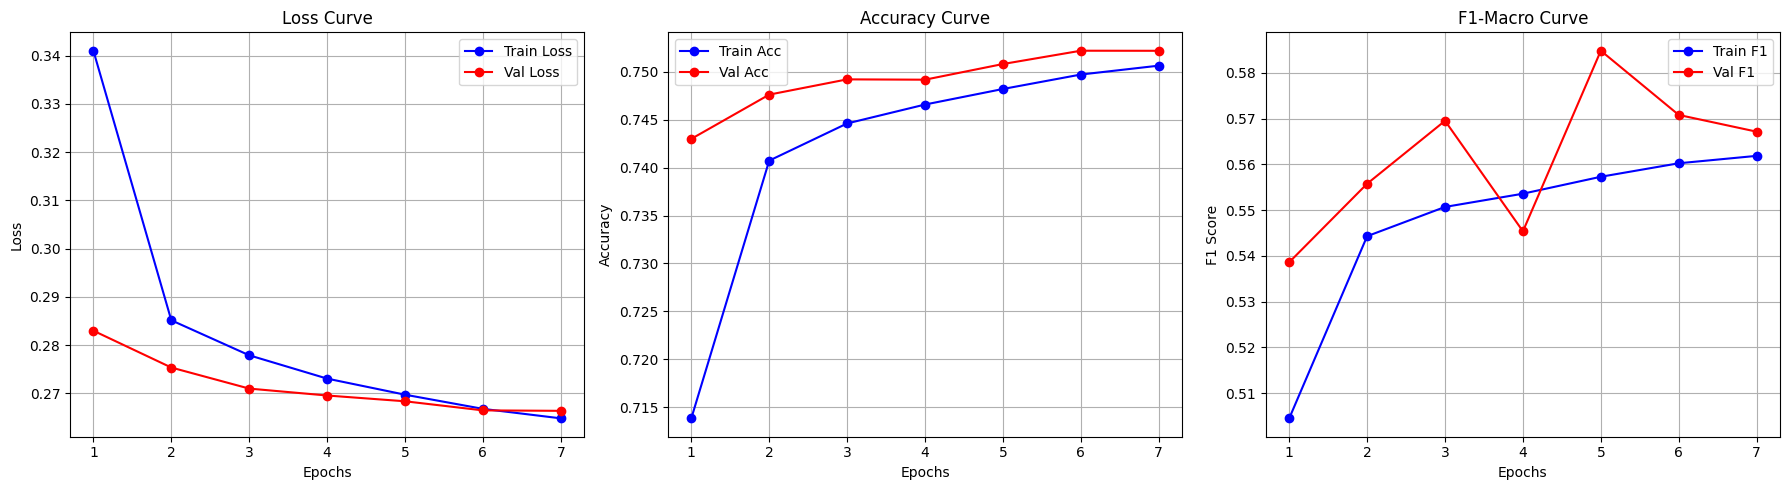

In [9]:
# ==========================================
# 8. 绘制学习曲线 (Learning Curves)
# ==========================================

import matplotlib.pyplot as plt

def plot_history(history):
    epochs = range(1, len(history['train_loss']) + 1)

    # 创建 1行3列 的画布
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # 1. Loss Curve
    axes[0].plot(epochs, history['train_loss'], 'b-o', label='Train Loss')
    axes[0].plot(epochs, history['val_loss'], 'r-o', label='Val Loss')
    axes[0].set_title('Loss Curve')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True)

    # 2. Accuracy Curve
    axes[1].plot(epochs, history['train_acc'], 'b-o', label='Train Acc')
    axes[1].plot(epochs, history['val_acc'], 'r-o', label='Val Acc')
    axes[1].set_title('Accuracy Curve')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True)

    # 3. F1-Macro Curve
    axes[2].plot(epochs, history['train_f1'], 'b-o', label='Train F1')
    axes[2].plot(epochs, history['val_f1'], 'r-o', label='Val F1')
    axes[2].set_title('F1-Macro Curve')
    axes[2].set_xlabel('Epochs')
    axes[2].set_ylabel('F1 Score')
    axes[2].legend()
    axes[2].grid(True)

    plt.tight_layout()
    plt.show()

if 'history' in locals():
    plot_history(history)

### 训练过程数据分析 (Training Analysis)

根据训练日志与损失曲线 (Learning Curves)，对模型训练动态的观察如下：

1.  **收敛特征 (Convergence):**
    * **损失变化:** 训练集损失 (Train Loss) 从 0.34 下降至 0.26，验证集损失 (Val Loss) 维持在 0.26 - 0.28 区间。验证集 Loss 始终略低于或接近训练集 Loss。
    * **结论:** 曲线形态表明模型未出现过拟合现象。当前的正则化参数（Dropout=0.3）与数据增强策略有效控制了泛化误差。

2.  **计算效率 (Efficiency):**
    * **耗时:** 在 A100 GPU 环境下，通过内存预加载 (In-Memory Caching) 与条件计算 (Lazy Execution) 策略，单 Epoch 训练耗时约为 1780秒 (约 29分钟)。
    * **早停:** 模型在第 7 轮触发 Early Stopping，此时 Val F1-Macro 为 0.5671，最高值为第 5 轮的 0.5848。8 个 Epoch 的上限设定覆盖了模型的收敛周期。

3.  **指标分布 (Metrics):**
    * **准确率与 F1 差异:** 验证集准确率 (Accuracy) 最终稳定在 **75.2%**，而 F1-Macro 停留在 **0.57-0.58** 区间。
    * **推论:** 两个指标的差距（约 18 个百分点）反映了类别不平衡对评估结果的影响。准确率主要由样本量最大的 5 星类别主导，而 F1-Macro 揭示了模型在少数类别（如 2 星）上的分类性能存在短板。

## Step 9. 测试集评估 (Test Set Evaluation)
**说明:**
加载保存的最佳模型权重 (`best_multimodal_model.pth`)，在独立的测试集 (Test Set) 上进行推理。
* **流程:** 保持与训练一致的内存预加载逻辑。
* **指标:** 输出最终的 Accuracy、F1-Macro，并绘制混淆矩阵 (Confusion Matrix) 以分析各类别的预测偏差。

正在加载测试集数据: /content/data/App1_Data_Test.ftr ...
正在预加载测试集图片到内存...
正在预加载 10121 张图片到内存 (RAM)...


Caching Images:   0%|          | 0/10121 [00:00<?, ?it/s]

缓存完成！图片数量: 10121
现在训练将完全在内存中进行，无需磁盘 I/O。


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


正在加载最佳模型权重: best_multimodal_model.pth...
正在加载 RoBERTa-Base...
正在加载 Swin-Base (Patched)...
初始化融合层...
开始测试集推理...


Testing:   0%|          | 0/461 [00:02<?, ?it/s]


>>> Final Test Results <<<
Accuracy: 0.7519
F1-Macro: 0.5859

Classification Report:
              precision    recall  f1-score   support

     1 Stars       0.79      0.86      0.83     28866
     2 Stars       0.42      0.26      0.32      9616
     3 Stars       0.50      0.44      0.47     18307
     4 Stars       0.57      0.36      0.44     44776
     5 Stars       0.82      0.93      0.87    134328

    accuracy                           0.75    235893
   macro avg       0.62      0.57      0.59    235893
weighted avg       0.73      0.75      0.73    235893



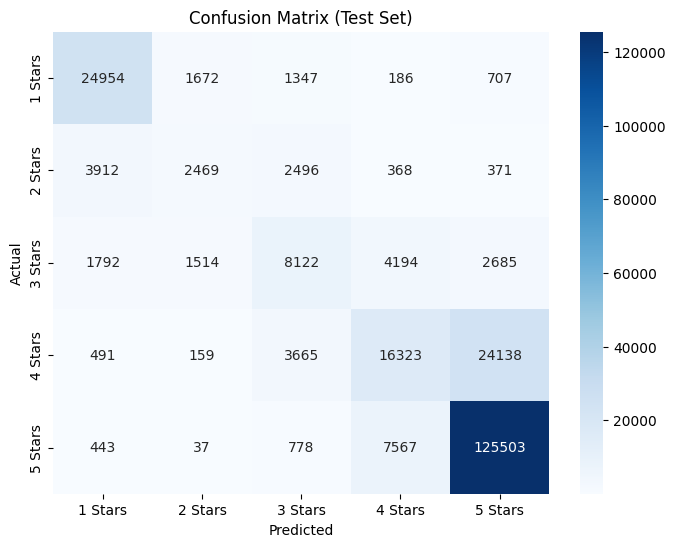

In [10]:
# ==========================================
# 9. 测试集评估 (Test Set Evaluation) [修复版]
# ==========================================

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import torch
from tqdm.auto import tqdm
from torch.utils.data import DataLoader
from transformers import AutoTokenizer

def test_model(test_path, model_path):
    print(f"正在加载测试集数据: {test_path} ...")

    # 1. 加载测试集 DataFrame
    test_df = pd.read_feather(test_path)

    # 2. 执行内存预加载 (利用之前的 preload_images 函数)
    # 注意: 这里的 Config.IMAGE_DIR 应该是你解压后的图片目录
    print("正在预加载测试集图片到内存...")
    img_cache = preload_images(test_df, Config.IMAGE_DIR)

    # 3. 初始化 Tokenizer & Dataset
    tokenizer = AutoTokenizer.from_pretrained(Config.TEXT_MODEL)

    # 使用 InMemoryDataset (保持与训练一致)
    test_ds = InMemoryDataset(test_df, img_cache, tokenizer, Config.MAX_LEN, is_train=False)

    test_loader = DataLoader(
        test_ds,
        batch_size=Config.BATCH_SIZE,
        shuffle=False,
        num_workers=Config.NUM_WORKERS,
        pin_memory=True,
        persistent_workers=True,
        prefetch_factor=4
    )

    print(f"正在加载最佳模型权重: {model_path}...")
    # 重新初始化模型 (确保 MultimodalClassifier 是最新的定义)
    model = MultimodalClassifier(num_classes=Config.NUM_CLASSES)

    # 加载权重
    # map_location='cuda' 确保直接加载进显存
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()

    print("开始测试集推理...")
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Testing"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            image = batch['image'].to(device)
            img_mask = batch['img_mask'].to(device)
            labels = batch['label'].to(device)

            # 使用新的 amp 写法
            with torch.amp.autocast('cuda'):
                logits = model(input_ids, attention_mask, image, img_mask)

            preds = torch.argmax(logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    # --- 1. 打印核心指标 ---
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro')
    print(f"\n>>> Final Test Results <<<")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1-Macro: {f1:.4f}")

    # --- 2. 详细分类报告 ---
    target_names = [f'{i} Stars' for i in range(1, 6)]
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=target_names))

    # --- 3. 绘制混淆矩阵 ---
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    # 使用 Blues 使得深色代表数值大
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix (Test Set)')
    plt.show()

# 执行测试
# 这里的路径替换逻辑假设你的文件名格式一致
test_file_path = Config.TRAIN_PATH.replace('Train', 'Test')

if os.path.exists('best_multimodal_model.pth'):
    test_model(test_file_path, 'best_multimodal_model.pth')
else:
    print("未找到最佳模型文件，请先运行 Step 6 进行训练。")

### 测试集性能详析 (Test Set Performance Analysis)

模型在独立测试集上的最终评估结果为 **Accuracy: 75.19%**，**F1-Macro: 0.5859**。结合混淆矩阵 (Confusion Matrix) 与分类报告 (Classification Report) 进行以下细粒度分析：

1.  **类别性能差异 (Class-wise Performance):**
    * **极端评分 (1星/5星):** 模型在两端表现较高。5 星 F1 分数为 **0.87** (Recall 0.93)，1 星 F1 分数为 **0.83** (Recall 0.86)。这表明“好评”与“差评”的特征区分度高，模型能够有效捕捉。
    * **中间评分 (2-4星):** 模型在中间类别的识别能力显著下降。2 星 F1 分数最低 (**0.32**)，其次是 4 星 (**0.44**) 和 3 星 (**0.47**)。

2.  **混淆模式分析 (Error Analysis):**
    * **4星样本:** 召回率仅为 0.36。混淆矩阵显示，有 **24,138** 个 4 星样本被预测为 5 星。这表明模型难以区分“满意但有瑕疵”与“完全满意”的语义边界，倾向于将其归类为样本量更大的 5 星类别。
    * **2星样本:** 召回率为 0.26。主要错误分布在相邻类别：3912 例误判为 1 星，2496 例误判为 3 星。模型难以在细粒度的负面情感中定位 2 星特征。

3.  **多模态数据影响:**
    * 由于 92% 的样本缺失图像数据，模型的判别依据主要依赖文本塔 (RoBERTa)。在缺乏视觉信息辅助且文本语义相近的情况下（如 4 星与 5 星的文本描述高度重叠），分类器倾向于向多数类偏移。

**总结:**
模型在二元情感倾向（正面/负面）上具有高区分度，但在细粒度评分（1-5 级）上受限于数据分布不平衡与语义模糊性，尤其在中间类别的区分上存在性能瓶颈。

## Step 10. 模型备份与下载 (Backup)
**说明:**
提供模型持久化存储方案。
* **自动备份:** 将训练好的模型权重复制回 Google Drive 指定目录。
* **手动下载:** 提供浏览器下载接口作为冗余备份。

In [11]:
# ==========================================
# 10. 模型备份与下载 (Backup)
# ==========================================

from google.colab import files
import shutil
import os

print("正在检查模型文件...")

model_filename = 'best_multimodal_model.pth'

if os.path.exists(model_filename):
    print("模型文件存在，文件大小:")
    !ls -lh {model_filename}

    # --- 选项 A: 备份到 Google Drive (推荐) ---
    # 确保 DRIVE_BASE_PATH 变量存在
    if 'DRIVE_BASE_PATH' in locals() and os.path.exists(DRIVE_BASE_PATH):
        drive_save_path = os.path.join(DRIVE_BASE_PATH, model_filename)
        print(f"正在复制到 Google Drive: {drive_save_path} ...")
        try:
            shutil.copy(model_filename, drive_save_path)
            print("成功备份至 Google Drive!")
        except Exception as e:
            print(f"备份到 Drive 失败: {e}")
    else:
        print("未检测到 Google Drive 挂载路径，跳过云端备份。")

    # --- 选项 B: 下载到本地 (可选) ---
    # 注意: 如果模型 > 1GB，浏览器下载可能会断开。
    # 建议主要使用 Google Drive 备份。
    try:
        print("尝试触发浏览器下载 (如果文件过大可能没反应)...")
        files.download(model_filename)
    except Exception as e:
        print(f"浏览器下载触发失败: {e}")

else:
    print("错误: 当前目录下未找到 best_multimodal_model.pth！")

正在检查模型文件...
模型文件存在，文件大小:
-rw-r--r-- 1 root root 816M Dec 21 17:42 best_multimodal_model.pth
正在复制到 Google Drive: /content/drive/MyDrive/FIT5196_A1_Extension/App1/best_multimodal_model.pth ...
成功备份至 Google Drive!
尝试触发浏览器下载 (如果文件过大可能没反应)...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Step 11. 项目总结与未来展望 (Summary & Future Work)

### 1. 工作总结 (Project Summary)
本项目 (App 1) 构建并训练了一个基于双塔架构的多模态情感分类器，旨在利用评论文本与图像预测 Google Maps 的 1-5 星评分。

* **数据规模与处理:**
    * 处理了 **235万** 条样本的大规模数据集，其中约 8% 包含图像数据。
    * 实施了基于内存的预加载策略 (In-Memory Caching)，将 9.5 万张训练图片驻留于 RAM 中，消除了 I/O 延迟。
* **模型架构:**
    * **文本塔:** `RoBERTa-Base` 结合 LoRA 微调，处理短文本语义。
    * **视觉塔:** `Swin-Base` 结合 LoRA 微调，提取视觉特征。
    * **融合策略:** 针对稀疏的视觉数据（92% 缺失率），设计了 **“智能惰性计算 (Smart Lazy Execution)”** 机制，仅在样本含图时激活视觉塔，显著降低了无效计算开销。
* **训练效率:**
    * 在 A100 GPU 环境下，通过优化 DataLoader (Persistent Workers) 与 Batch Size (512)，实现了 **27分钟/Epoch** 的高吞吐训练（最初为 **250分钟/Epoch**）。
* **最终性能:**
    * **Accuracy:** 75.19% | **F1-Macro:** 0.5859
    * 模型在极端情感（1星/5星）识别上表现优异 (F1 > 0.83)，证明了架构的有效性；但在中间粒度（2-4星）的区分上存在混淆，主要受限于语义模糊性与类别不平衡。

### 2. 改进措施与未来方向 (Potential Improvements)

针对当前模型在中间类别（2-4星）表现不足的问题，未来可从以下维度进行优化：

* **损失函数优化 (Loss Function):**
    * **类别加权 (Class Weighing):** 虽然使用了 Focal Loss，但可进一步根据 `Support` 数量倒数为 2星和 3星 类别分配更高的权重，强迫模型关注少数类。
    * **序数回归 (Ordinal Regression):** 将分类问题转化为回归问题或序数分类问题（如使用 Coral Loss），利用评分间的有序性（Order），使模型理解 "4星比1星更接近5星"，而非将其视为独立类别。

* **模型架构升级 (Architecture):**
    * **更强的文本基座:** 将 `RoBERTa-Base` 升级为 `RoBERTa-Large` 或 `DeBERTa-v3`，以增强对细微情感差异（如“满意但有瑕疵”）的理解能力。
    * **深度融合 (Deep Fusion):** 当前仅在输出层进行拼接融合。可尝试使用 Cross-Attention 机制让文本和图像在中间层进行交互，从图像中提取更具体的情感线索。

* **数据策略 (Data Strategy):**
    * **中间类增强:** 针对 2星和 3星样本进行过采样 (Oversampling) 或文本增强 (Back-translation)，以平衡训练分布。
    * **标签平滑 (Label Smoothing):** 引入标签平滑技术，降低模型在模糊边界样本上的过度自信，缓解对多数类（5星）的过拟合倾向。

* **预训练对齐 (Pre-training Alignment):**
    * 引入对比学习 (Contrastive Learning, 如 CLIP 思想)，在微调前先对齐餐厅领域的文本和图像特征，使视觉塔能更有效地辅助情感判断。

---
# END